In [1]:
import os
import re
import json
import kagglehub
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
import matplotlib.pyplot as plt
import seaborn as sns

/home/mastermind/ielts_pred/venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-01-31 16:09:11.493270: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# 2) Config
project_root = "/home/mastermind/ielts_pred"
path = kagglehub.dataset_download("mazlumi/ielts-writing-scored-essays-dataset")
MODEL_SAVE_PATH = "src/model/bert_ielts_model_v3.pt"

BERT_MODEL = "distilbert-base-uncased"
MAX_SEQ_LEN = 256
BATCH_SIZE = 4
GRADIENT_ACCUMULATION_STEPS = 4
EPOCHS = 30
LEARNING_RATE = 1.5e-5
WEIGHT_DECAY = 0.02
DROPOUT = 0.35
FREEZE_BERT_LAYERS = 3
WARMUP_STEPS = 100
EARLY_STOP_PATIENCE = 6
LABEL_SMOOTHING = 0.05

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

100%|██████████| 674k/674k [00:00<00:00, 2.76MB/s]

Extracting files...
Device: cuda


In [5]:
df = pd.read_csv(path + "/ielts_writing_dataset.csv")
df.head()

,Task_Type,Question,Essay,Examiner_Commen,Task_Response,Coherence_Cohesion,Lexical_Resource,Range_Accuracy,Overall
0,1,The bar chart below describes some changes abo...,"Between 1995 and 2010, a study was conducted r...",NaN,NaN,NaN,NaN,NaN,5.5
1,2,Rich countries often give money to poorer coun...,Poverty represents a worldwide crisis. It is t...,NaN,NaN,NaN,NaN,NaN,6.5
2,1,The bar chart below describes some changes abo...,The left chart shows the population change hap...,NaN,NaN,NaN,NaN,NaN,5.0
3,2,Rich countries often give money to poorer coun...,Human beings are facing many challenges nowada...,NaN,NaN,NaN,NaN,NaN,5.5
4,1,The graph below shows the number of overseas v...,Information about the thousands of visits from...,NaN,NaN,NaN,NaN,NaN,7.0


In [7]:
df = df[["Essay", "Overall"]].dropna() 
df = df[~df.duplicated(subset=["Essay"], keep="first")].reset_index(drop=True)
df["Scaled"] = df["Overall"] / 9.0
df.head()


,Essay,Overall,Scaled
0,"Between 1995 and 2010, a study was conducted r...",5.5,0.611111
1,Poverty represents a worldwide crisis. It is t...,6.5,0.722222
2,The left chart shows the population change hap...,5.0,0.555556
3,Human beings are facing many challenges nowada...,5.5,0.611111
4,Information about the thousands of visits from...,7.0,0.777778


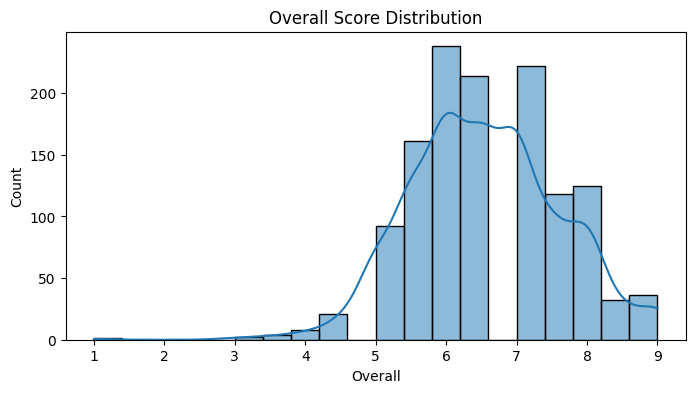

In [8]:
plt.figure(figsize=(8, 4))
sns.histplot(df["Overall"], bins=20, kde=True)
plt.title("Overall Score Distribution")
plt.xlabel("Overall")
plt.ylabel("Count")
plt.show()

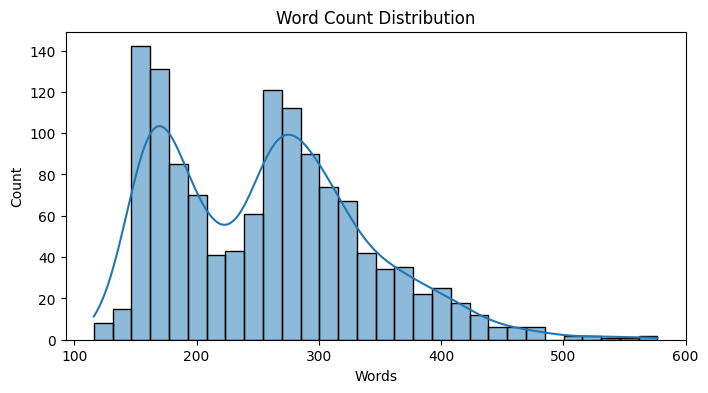

In [9]:
df["word_count"] = df["Essay"].str.split().apply(len)
plt.figure(figsize=(8, 4))
sns.histplot(df["word_count"], bins=30, kde=True)
plt.title("Word Count Distribution")
plt.xlabel("Words")
plt.ylabel("Count")
plt.show()

In [10]:
def extract_linguistic_features(essay: str) -> np.ndarray:
    words = essay.split()
    sentences = re.split(r"[.!?]+", essay)
    sentences = [s.strip() for s in sentences if s.strip()]

    features = [
        len(words),
        len(sentences) if sentences else 1,
        len(words) / max(len(sentences), 1),
        len(set(w.lower() for w in words)) / max(len(words), 1),
        len(essay),
        sum(1 for c in essay if c.isupper()) / max(len(essay), 1),
        essay.count(",") / max(len(words), 1),
        essay.count(".") / max(len(sentences), 1),
        sum(len(w) for w in words) / max(len(words), 1),
        sum(1 for w in words if w.lower() in {
            "however","moreover","furthermore","therefore","consequently",
            "nevertheless","additionally","specifically","particularly"
        }) / max(len(words), 1)
    ]
    return np.array(features, dtype="float32")

def normalise_features(features_list):
    features = np.array(features_list)
    mean = features.mean(axis=0)
    std = features.std(axis=0) + 1e-8
    normalized = (features - mean) / std
    return normalized, mean, std

In [13]:
bins = pd.qcut(df["Overall"], q=5, duplicates="drop")
bin_counts = bins.value_counts()
valid_bins = bin_counts[bin_counts >= 2].index
mask = bins.isin(valid_bins)

df_safe = df[mask].copy()
bins_safe = pd.qcut(df_safe["Overall"], q=min(5, df_safe["Overall"].nunique()), duplicates="drop")

train_df, val_df = train_test_split(
    df_safe,
    test_size=0.18,
    random_state=42,
    stratify=bins_safe
)
print("Train:", len(train_df))
print("Val:", len(val_df))

Train: 1044
Val: 230


In [15]:
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)

def tokenise_essays(essays, max_len=MAX_SEQ_LEN):
    if hasattr(essays, "tolist"):
        essays = essays.tolist()
    encoded = tokenizer(
        essays,
        max_length=max_len,
        padding="max_length",
        truncation=True,
        return_tensors=None
    )
    input_ids = torch.tensor(encoded["input_ids"], dtype=torch.long)
    attention_mask = torch.tensor(encoded["attention_mask"], dtype=torch.long)
    return input_ids, attention_mask

X_train_ids, X_train_mask = tokenise_essays(train_df["Essay"])
X_val_ids, X_val_mask = tokenise_essays(val_df["Essay"])

In [17]:
train_features = [extract_linguistic_features(e) for e in train_df["Essay"].values]
val_features = [extract_linguistic_features(e) for e in val_df["Essay"].values]

train_features_norm, feat_mean, feat_std = normalise_features(train_features)
val_features_norm = (np.array(val_features) - feat_mean) / feat_std

# Save normalization stats
np.save(os.path.join(project_root, "bert_features_mean_v3.npy"), feat_mean)
np.save(os.path.join(project_root, "bert_features_std_v3.npy"), feat_std)

X_train_feat = torch.tensor(train_features_norm, dtype=torch.float32)
X_val_feat = torch.tensor(val_features_norm, dtype=torch.float32)

y_train = torch.tensor(train_df["Scaled"].values, dtype=torch.float32)
y_val = torch.tensor(val_df["Scaled"].values, dtype=torch.float32)

In [18]:
train_dataset = TensorDataset(X_train_ids, X_train_mask, X_train_feat, y_train)
val_dataset = TensorDataset(X_val_ids, X_val_mask, X_val_feat, y_val)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

In [19]:
class BERTIELTSScorer(nn.Module):
    def __init__(self, bert_model_name=BERT_MODEL, num_features=10, dropout=0.35, freeze_bert_layers=2):
        super().__init__()
        self.bert = AutoModel.from_pretrained(bert_model_name)

        if freeze_bert_layers > 0:
            for i, layer in enumerate(self.bert.transformer.layer):
                if i < freeze_bert_layers:
                    for param in layer.parameters():
                        param.requires_grad = False

        self.bert_hidden_size = self.bert.config.hidden_size
        self.feature_network = nn.Sequential(
            nn.Linear(num_features, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 32),
            nn.LayerNorm(32),
            nn.ReLU(),
            nn.Dropout(dropout * 0.7)
        )
        combined_size = self.bert_hidden_size + 32
        self.prediction_head = nn.Sequential(
            nn.Linear(combined_size, 256),
            nn.LayerNorm(256),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(256, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout * 0.7),
            nn.Linear(64, 1)
        )

    def forward(self, input_ids, attention_mask, features):
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = bert_output.last_hidden_state[:, 0, :]
        feature_embedding = self.feature_network(features)
        combined = torch.cat([cls_embedding, feature_embedding], dim=-1)
        return self.prediction_head(combined).squeeze(-1)

model = BERTIELTSScorer(
    bert_model_name=BERT_MODEL,
    num_features=10,
    dropout=DROPOUT,
    freeze_bert_layers=FREEZE_BERT_LAYERS
).to(device)